In [1]:
from os.path import basename, exists


def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)


download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/thinkstats.py")

Downloaded thinkstats.py


In [2]:
try:
    import empiricaldist
except ImportError:
    %pip install empiricaldist

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for empiricaldist: filename=empiricaldist-0.9.0-py3-none-any.whl size=14297 sha256=2d219a28535e86d0e9de5cb8318edb75c5f3f72b665820fa6457b3e3a32497ab
  Stored in directory: /root/.cache/pip/wheels/26/56/da/ea90b6b66dc5e72379a64e2819815066873f00c1350126e876
Successfully built empiricaldist


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from thinkstats import decorate

In [4]:
from empiricaldist import FreqTab

ftab = FreqTab.from_seq([1, 2, 2, 3, 5])
ftab

,
1,1
2,2
3,1
5,1


In [5]:
n = ftab.sum()
n

np.int64(5)

In [6]:
pmf = ftab / n
pmf

,
1,0.2
2,0.4
3,0.2
5,0.2


In [7]:
pmf.sum()

np.float64(1.0)

In [8]:
from empiricaldist import Pmf

pmf = Pmf.from_seq([1, 2, 2, 3, 5])
pmf

,
1,0.2
2,0.4
3,0.2
5,0.2


In [9]:
pmf.sum()

np.float64(1.0)

In [10]:
pmf[2]

np.float64(0.4)

In [11]:
pmf(2)

np.float64(0.4)

In [12]:
pmf[2] = 0.2
pmf(2)

np.float64(0.2)

In [13]:
pmf[2] += 0.3
pmf[2]

np.float64(0.5)

In [14]:
pmf[2] *= 0.5
pmf[2]

np.float64(0.25)

In [15]:
pmf.sum()

np.float64(0.8500000000000001)

In [16]:
pmf.normalize()

np.float64(0.8500000000000001)

In [17]:
pmf.copy()

,
1,0.235294
2,0.294118
3,0.235294
5,0.235294


In [18]:
seq = [1, 2, 2, 3, 5]

n = len(seq)
mean = np.sum(seq) / n
mean

np.float64(2.6)

In [19]:
pmf = Pmf.from_seq(seq)

In [20]:
mean = np.sum(pmf.ps * pmf.qs)
mean

np.float64(2.6)

In [21]:
pmf.mean()

np.float64(2.6)

In [22]:
deviations = pmf.qs - mean

In [23]:
var = np.sum(pmf.ps * deviations**2)
var

np.float64(1.84)

In [24]:
pmf.var()

np.float64(1.84)

In [25]:
np.sqrt(var)

np.float64(1.3564659966250536)

In [26]:
pmf.std()

np.float64(1.3564659966250536)

In [27]:
pmf.mode()

np.int64(2)

In [28]:
ranges = pd.interval_range(start=5, end=50, freq=5, closed="left")
ranges.name = "class size"

data = pd.DataFrame(index=ranges)
data["count"] = [8, 8, 14, 4, 6, 12, 8, 3, 2]
data

,count
class size,
"[5, 10)",8
"[10, 15)",8
"[15, 20)",14
"[20, 25)",4
"[25, 30)",6
"[30, 35)",12
"[35, 40)",8
"[40, 45)",3
"[45, 50)",2


In [29]:
sizes = ranges.left + 2
sizes

Index([7, 12, 17, 22, 27, 32, 37, 42, 47], dtype='int64')

In [30]:
counts = data["count"]
actual_pmf = Pmf(counts, sizes, name="actual")
actual_pmf.normalize()

np.int64(65)

In [31]:
actual_pmf.mean()

np.float64(23.692307692307693)

In [32]:
def bias(pmf, name):
    # multiply each probability by class size
    ps = pmf.ps * pmf.qs

    # make a new Pmf and normalize it
    new_pmf = Pmf(ps, pmf.qs, name=name)
    new_pmf.normalize()
    return new_pmf

In [33]:
observed_pmf = bias(actual_pmf, name="observed")

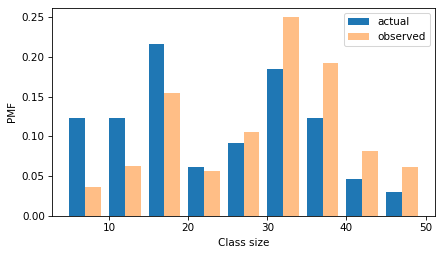

In [34]:
from thinkstats import two_bar_plots

two_bar_plots(actual_pmf, observed_pmf, width=2)
decorate(xlabel="Class size", ylabel="PMF")

In [35]:
observed_pmf.mean()

np.float64(29.123376623376622)

In [36]:
def unbias(pmf, name):
    # divide each probability by class size
    ps = pmf.ps / pmf.qs

    new_pmf = Pmf(ps, pmf.qs, name=name)
    new_pmf.normalize()
    return new_pmf

In [37]:
debiased_pmf = unbias(observed_pmf, "debiased")
debiased_pmf.mean()

np.float64(23.692307692307693)

In [38]:
try:
    import statadict
except ImportError:
    %pip install statadict

In [39]:
download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/nsfg.py")
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemPreg.dct")
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemPreg.dat.gz")

Downloaded nsfg.py
Downloaded 2002FemPreg.dct
Downloaded 2002FemPreg.dat.gz


In [40]:
from nsfg import get_nsfg_groups

live, firsts, others = get_nsfg_groups()

In [41]:
first_pmf = Pmf.from_seq(firsts["prglngth"], name="firsts")
other_pmf = Pmf.from_seq(others["prglngth"], name="others")

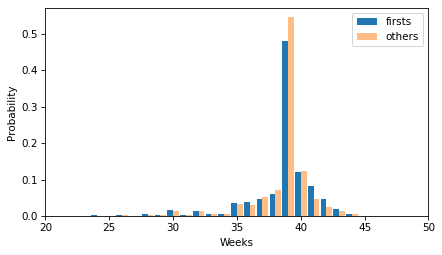

In [42]:
two_bar_plots(first_pmf, other_pmf)
decorate(xlabel="Weeks", ylabel="Probability", xlim=[20, 50])

In [43]:
weeks = range(35, 46)
first_pmf(weeks)

array([0.03602991, 0.03897575, 0.04713347, 0.06163608, 0.4790392 ,
       0.12145932, 0.08157716, 0.04645366, 0.01971448, 0.00521187,
       0.00135962])

In [44]:
other_pmf(weeks)

array([0.03210137, 0.03146779, 0.05216473, 0.07074974, 0.54466737,
       0.12249208, 0.04794087, 0.02597677, 0.01288279, 0.00485744,
       0.00084477])

In [45]:
diffs = first_pmf(weeks) - other_pmf(weeks)
diffs

array([ 0.00392854,  0.00750796, -0.00503126, -0.00911366, -0.06562817,
       -0.00103276,  0.03363629,  0.02047689,  0.00683169,  0.00035443,
        0.00051485])

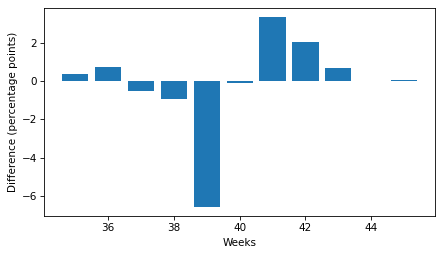

In [46]:
plt.bar(weeks, diffs * 100)
decorate(xlabel="Weeks", ylabel="Difference (percentage points)")

In [47]:
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemResp.dct")
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemResp.dat.gz")

Downloaded 2002FemResp.dct
Downloaded 2002FemResp.dat.gz


In [48]:
from nsfg import read_fem_resp

resp = read_fem_resp()
resp.shape

(7643, 3092)

In [61]:
from empiricaldist import FreqTab, Pmf
import numpy as np
import matplotlib.pyplot as plt

numbabes
0     3229
1     1519
2     1603
3      828
4      309
5       95
6       29
7       15
8        8
9        2
10       3
16       1
22       1
97       1
Name: , dtype: int64
numbabes
0     3229
1     1519
2     1603
3      828
4      309
5       95
6       29
7       15
8        8
9        2
10       3
16       1
22       1
97       1
Name: , dtype: int64


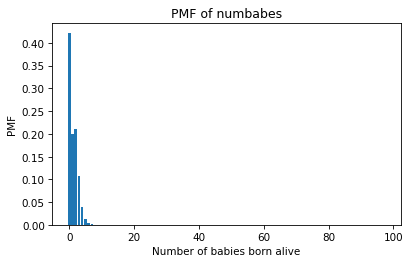

In [65]:
# Exercise 3.1

# Select the column
numbabes = resp['numbabes']

# Frequency table
freq = FreqTab.from_seq(numbabes)
print(freq)

# Check for special values
print(freq.sort_index())

# Replace special values with NaN
numbabes_clean = numbabes.replace([98, 99], np.nan)

# Create PMF
pmf_numbabes = Pmf.from_seq(numbabes_clean.dropna())

# Plot PMF
pmf_numbabes.bar()

plt.xlabel("Number of babies born alive")
plt.ylabel("PMF")
plt.title("PMF of numbabes")
plt.show()

In [66]:
# Exercise 3.2

# Compute skewness directly from sample
x = numbabes_clean.dropna()

mean = x.mean()
std = x.std()

skewness = np.mean(((x - mean) / std) ** 3)

print("Sample skewness:", skewness)

Sample skewness: 21.548220817304916


In [67]:
# Function to compute skewness from a PMF

def pmf_skewness(pmf):
    mean = pmf.mean()
    std = pmf.std()

    deviations = pmf.qs - mean

    skew = np.sum(((deviations / std) ** 3) * pmf.ps)

    return skew

In [ ]:
# Compute skewness using PMF
pmf_skew = pmf_skewness(pmf_numbabes)

print("PMF skewness:", pmf_skew)

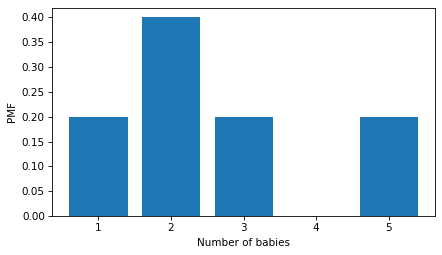

In [64]:
pmf.bar()
decorate(xlabel="Number of babies", ylabel="PMF")

In [53]:
numbabes = resp["numbabes"].replace(97, np.nan)

In [68]:
# Exercise 3.3

# Select numkdhh column
numkdhh = resp['numkdhh']

# Replace special values if present
numkdhh_clean = numkdhh.replace([98, 99], np.nan)

# Create PMF
pmf_actual = Pmf.from_seq(numkdhh_clean.dropna())

print(pmf_actual)

numkdhh
0    0.466178
1    0.214052
2    0.196258
3    0.087139
4    0.025644
5    0.010729
Name: , dtype: float64


In [69]:
# Bias function

def bias(pmf):
    biased_pmf = Pmf()

    for x, p in pmf.items():
        biased_pmf[x] = x * p

    biased_pmf.normalize()

    return biased_pmf

In [70]:
# Create biased distribution
pmf_biased = bias(pmf_actual)

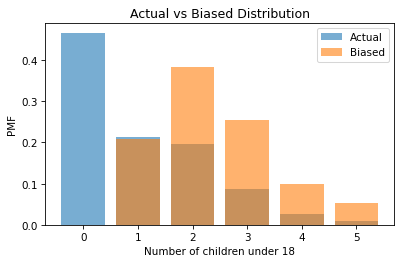

In [71]:
# Plot both distributions

pmf_actual.bar(label='Actual', alpha=0.6)
pmf_biased.bar(label='Biased', alpha=0.6)

plt.xlabel("Number of children under 18")
plt.ylabel("PMF")
plt.title("Actual vs Biased Distribution")
plt.legend()

plt.show()

In [72]:
# Compute means

print("Actual mean:", pmf_actual.mean())
print("Biased mean:", pmf_biased.mean())

Actual mean: 1.024205155043831
Biased mean: 2.403679100664282


In [54]:
deviations = numbabes - numbabes.mean()
skewness = np.mean(deviations**3) / numbabes.std(ddof=0) ** 3
skewness

np.float64(1.7018914266755378)